# Fusion2 results

**Quantification workflow:** DDA  
**Preprocessing profile:** `dda_missingness_v1`

The VAE is trained on good QC samples, and the MLP classifies good and bad samples from the eight-dimensional VAE latent mean. The table below reports the five folds used in the manuscript analysis.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd().resolve()
project_root = next(
    (
        candidate
        for candidate in [cwd, *cwd.parents]
        if (candidate / "results" / "summary_metrics.csv").exists()
    ),
    None,
)
if project_root is None:
    raise RuntimeError("Run this notebook from inside the project repository.")


In [2]:
summary = pd.read_csv(project_root / 'results' / 'summary_metrics.csv')
folds = pd.read_csv(project_root / 'results' / 'cv_metrics.csv')
display(summary[summary['instrument'] == 'fusion2'].round(4))
display(folds[folds['instrument'] == 'fusion2'].round(4))

,instrument,quantification,n_samples,n_good,n_bad,auc_mean,auc_sd,accuracy_mean,f1_bad_mean
0,fusion2,DDA,120,85,35,0.9814,0.0172,0.9584,0.9346


,instrument,quantification,fold,auc,accuracy,precision_bad,recall_bad,specificity_good,f1_bad,threshold
0,fusion2,DDA,1,0.958,0.958,1.000,0.857,1.000,0.923,0.9939
1,fusion2,DDA,2,1.000,1.000,1.000,1.000,1.000,1.000,0.9521
2,fusion2,DDA,3,1.000,1.000,1.000,1.000,1.000,1.000,0.9994
3,fusion2,DDA,4,0.983,0.917,0.778,1.000,0.882,0.875,0.1017
4,fusion2,DDA,5,0.966,0.917,0.778,1.000,0.882,0.875,0.8174


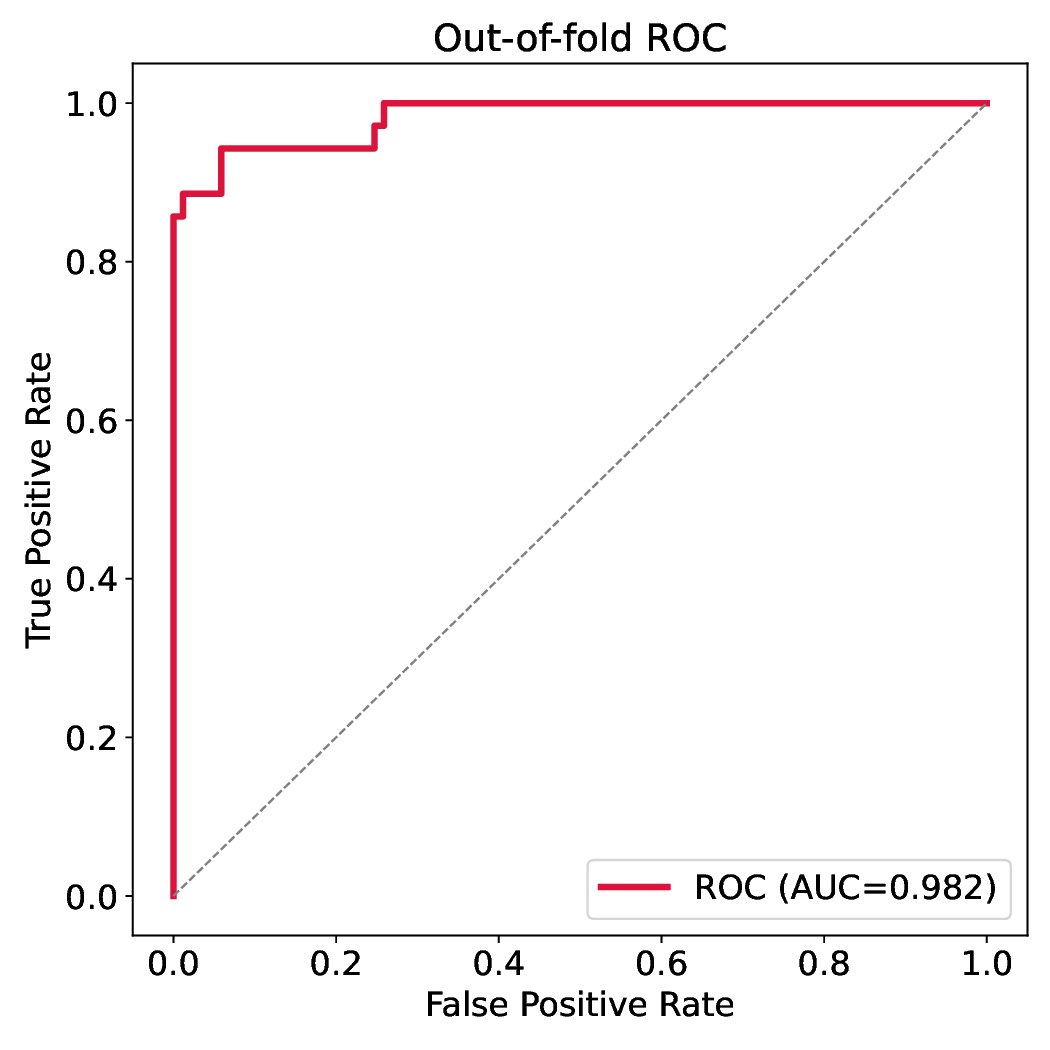

In [3]:
display(Image(filename=project_root / 'results' / 'figures' / 'roc' / 'fusion2_roc.png'))

## Reuse

The pretrained checkpoint is distributed as `fusion2.pt` with the data and model archive. See the repository README for download and inference commands.